# Allen Layer-4 perisomatic reference test

> Can the downloaded Allen Cell Types biophysical model run correctly in the current BioNet/NEURON environment?

The simulation uses the **original Allen morphology**, **original Allen fitted parameters**, and **original Allen NMODL mechanisms**. No MICrONS morphology, connectivity, functional data, or inferred synaptic physiology is used here.



In [1]:
from microns20.config import find_project_root
from microns20.simulation import (
    allen_reference_spikes,
    compile_run_mechanisms,
    plot_allen_reference_voltage,
    prepare_allen_reference_run,
    run_allen_reference,
    validate_allen_reference_assets,
)

project_root = find_project_root()
project_root


PosixPath('<PROJECT_ROOT>')

## 1. Validate the downloaded Allen model

The temperature and initial voltage are read from `fit_parameters.json`; 

In [2]:
allen_model = validate_allen_reference_assets(project_root)
allen_model


{'source_dir': PosixPath('<PROJECT_ROOT>/data/external/allen_cell_types/487245719'),
 'model_id': 487245719,
 'specimen_id': 486893033,
 'reconstruction_id': 512328466,
 'model_name': 'Biophysical - perisomatic_Scnn1a-Tg3-Cre;Ai14-209101.04.01.01',
 'celsius': 34.0,
 'v_init_mv': -84.59716796875,
 'n_modfiles': 16,
 'modfiles': ['CaDynamics.mod',
  'Ca_HVA.mod',
  'Ca_LVA.mod',
  'Ih.mod',
  'Im.mod',
  'Im_v2.mod',
  'K_P.mod',
  'K_T.mod',
  'Kd.mod',
  'Kv2like.mod',
  'Kv3_1.mod',
  'NaTa.mod',
  'NaTs.mod',
  'NaV.mod',
  'Nap.mod',
  'SK.mod']}

## 2. Prepare a self-contained BioNet run

This builds a one-node SONATA network and copies the Allen morphology, fitted parameters, and `.mod` sources into `runs/allen_reference_smoke_test/`.


In [3]:
run_info = prepare_allen_reference_run(
    project_root,
    overwrite=True,
)

run_info


{'source_dir': PosixPath('<PROJECT_ROOT>/data/external/allen_cell_types/487245719'),
 'model_id': 487245719,
 'specimen_id': 486893033,
 'reconstruction_id': 512328466,
 'model_name': 'Biophysical - perisomatic_Scnn1a-Tg3-Cre;Ai14-209101.04.01.01',
 'celsius': 34.0,
 'v_init_mv': -84.59716796875,
 'n_modfiles': 16,
 'modfiles': ['CaDynamics.mod',
  'Ca_HVA.mod',
  'Ca_LVA.mod',
  'Ih.mod',
  'Im.mod',
  'Im_v2.mod',
  'K_P.mod',
  'K_T.mod',
  'Kd.mod',
  'Kv2like.mod',
  'Kv3_1.mod',
  'NaTa.mod',
  'NaTs.mod',
  'NaV.mod',
  'Nap.mod',
  'SK.mod'],
 'run_dir': PosixPath('<PROJECT_ROOT>/runs/allen_reference_smoke_test'),
 'config_file': PosixPath('<PROJECT_ROOT>/runs/allen_reference_smoke_test/config.json'),
 'network_dir': PosixPath('<PROJECT_ROOT>/runs/allen_reference_smoke_test/network'),
 'mechanisms_dir': PosixPath('<PROJECT_ROOT>/runs/allen_reference_smoke_test/components/mechanisms'),
 'population_name': 'allen_reference',
 'current_clamp_amp_na': 0.2,
 'current_clamp_delay_ms'

## 3. Compile the copied mechanisms


In [4]:
mechanism_library = compile_run_mechanisms(run_info)
mechanism_library


PosixPath('<PROJECT_ROOT>/runs/allen_reference_smoke_test/components/mechanisms/x86_64/libnrnmech.so')

## 4. Run BioNet

The current clamp is a simple proof-of-concept stimulus. Its amplitude is not a MICrONS-derived physiological quantity.


In [5]:
output_dir = run_allen_reference(run_info)
output_dir


2026-08-26 12:47:40,305 [INFO] Created log file


INFO:NEURONIOUtils:Created log file


2026-08-26 12:47:40,398 [INFO] Building cells.


INFO:NEURONIOUtils:Building cells.


2026-08-26 12:47:40,452 [INFO] Building recurrent connections


...

2026-08-26 12:47:40,922 [INFO]     step:10000 t_sim:1000.00 ms


INFO:NEURONIOUtils:    step:10000 t_sim:1000.00 ms


2026-08-26 12:47:40,934 [INFO] Simulation completed in 0.4709 seconds 


INFO:NEURONIOUtils:Simulation completed in 0.4709 seconds 


PosixPath('<PROJECT_ROOT>/runs/allen_reference_smoke_test/output')

## 5. Inspect spikes

In [6]:
spikes = allen_reference_spikes(run_info)
display(spikes)
print(f"Number of detected spikes: {len(spikes)}")


,timestamps,node_ids,population
0,224.7,0,allen_reference
1,232.2,0,allen_reference
2,285.1,0,allen_reference
3,295.2,0,allen_reference
4,345.5,0,allen_reference
5,355.7,0,allen_reference
6,405.8,0,allen_reference
7,416.5,0,allen_reference
8,466.4,0,allen_reference
9,477.1,0,allen_reference


Number of detected spikes: 16


## 6. Plot somatic membrane voltage

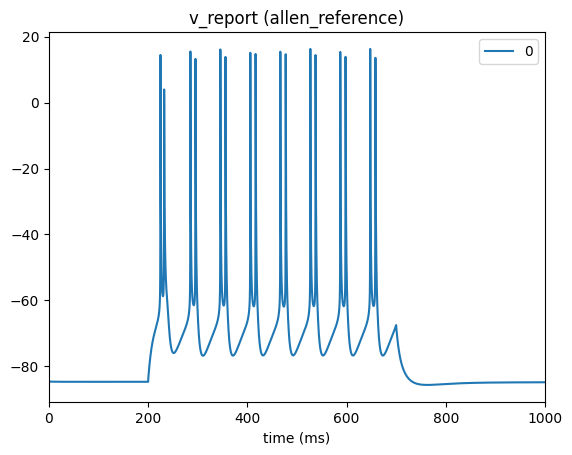

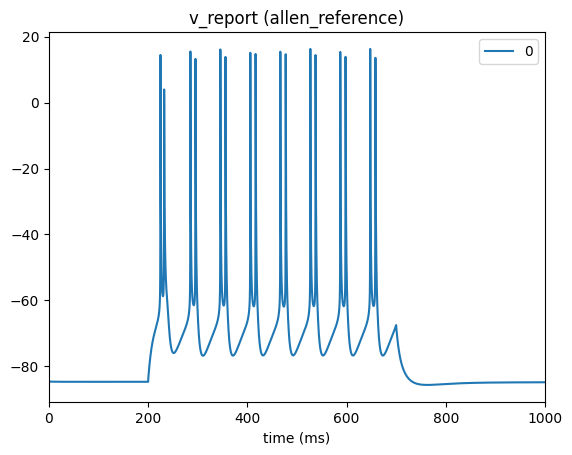

In [7]:
plot_allen_reference_voltage(run_info)
